In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/diabetes-health-indicators-dataset")
print("Dataset path:", path)


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")
print(f"Random seed set to: {RANDOM_SEED}")

# Load dataset correctly
df = pd.read_csv(f"{path}/diabetes_dataset.csv")
print(df.shape)
print(df.columns) # Display column names (our features)
print(df.dtypes)
df.head(10) # Display first 10 records

print("Dataset before cleaning:")
for column in df.columns:
    if np.issubdtype(df[column].dtype, np.number):
        print(f"{column:<40} Mean: {df[column].mean():>8.3f} | Median: {df[column].median():>8.3f}")

# Handling Null Values (empty records)
df_null = df.isnull() # bool
total_null = df_null.sum().sum() # count

print(f"Total Before:   {total_null} null") # Summing up null values for each column before handling
print(df.shape)

df_cleaned = df.copy()

# Handling Outliers
exclude_columns = ['family_history_diabetes','hypertension_history','cardiovascular_history','diagnosed_diabetes'] # Categorical columns to exclude (These are True/False binary values)
for col in exclude_columns:
    df_cleaned[col] = df_cleaned[col].clip(0,1) # reassigns any outliers to the closest bounds (0 or 1)

allowed_columns = df_cleaned.select_dtypes(include=[np.number]).columns.difference(exclude_columns) # columns to check for outliers

# Using IQR https://www.kaggle.com/code/aman2626786/outlier-removal-using-iqr-method
# This removes around 16k records from original 100k records
for col in allowed_columns:
    p25 = df_cleaned[col].quantile(0.25)
    p75 = df_cleaned[col].quantile(0.75)
    iqr = p75 - p25
    lower_bound = p25 - 1.5 * iqr
    upper_bound = p75 + 1.5 * iqr
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)] # Remove outliers

# Handling duplicate and empty records
df_cleaned = df_cleaned.drop_duplicates().dropna().drop('diabetes_stage', axis=1) # Drop duplicates, empty records, and 'diabetes_stage' column


for column in df_cleaned.columns:
    if df_cleaned[column].isnull().sum() > 0: # Check column datatypes if there exists null values
        if df_cleaned[column].dtype in [np.float64, np.int64]: # Numerical variables
            print(f"{column} contains {df_cleaned[column].isnull().sum()} null values.")
            df_cleaned[column] = df_cleaned[column].fillna(df_cleaned[column].median())
        else:
            df_cleaned[column] = df_cleaned[column].fillna("UNKNOWN") # Categorical variables

cleandf_null = df_cleaned.isnull() # bool

print(f"Total After:    {cleandf_null.sum().sum()} null") # Summing up null values for each column
print(df_cleaned.shape)

print("Dataset after cleaning:")
for column in df_cleaned.columns:
    if np.issubdtype(df_cleaned[column].dtype, np.number):
        print(f"{column:<40} Mean: {df_cleaned[column].mean():>8.3f} | Median: {df_cleaned[column].median():>8.3f}")

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

nominal_columns = ['gender', 'ethnicity', 'employment_status']
ordinal_columns = ['education_level', 'income_level', 'smoking_status']
ordinal_categories = [
    ['No formal', 'Highschool', 'Graduate', 'Postgraduate'],  # education_level
    ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],  # income_level
    ['Never', 'Former', 'Current']  # smoking_status
]

# One Hot Encoding
df_feature = df_cleaned.copy()
df_feature = pd.get_dummies(df_feature, columns=nominal_columns,drop_first=True,dtype=int)

# Ordinal Encoding
encoder = OrdinalEncoder(categories=ordinal_categories)
df_feature[ordinal_columns] = encoder.fit_transform(df_feature[ordinal_columns])

#df_feature will be used on forward instead of df_clean btw

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Dataset path: /kaggle/input/diabetes-health-indicators-dataset
Libraries imported successfully!
Random seed set to: 42
(100000, 31)
Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')
age                                     int64
gender                                 ob

In [ ]:
# ==============================
# Correlation with diagnosed_diabetes
# ==============================
strong_corr = {}      # save positively correlated features here
inv_strong_corr = {}  # save negatively correlated features here

target_col = 'diagnosed_diabetes'
features = df_feature.columns.difference([target_col])

for col in features:
    # Only compute correlation for numeric columns
    if np.issubdtype(df_feature[col].dtype, np.number):
        corr_val = df_feature[col].corr(df_feature[target_col])
        if corr_val > 0.3:      # moderate/strong positive correlation
            strong_corr[col] = corr_val
            print(f"Positive correlation - {col}: {corr_val:.3f}")
        elif corr_val < -0.3:   # moderate/strong negative correlation
            inv_strong_corr[col] = corr_val
            print(f"Negative correlation - {col}: {corr_val:.3f}")

# Optional: inspect dictionaries
# print("Strong positive correlations:", strong_corr)
# print("Strong negative correlations:", inv_strong_corr)


# ==============================
# AGE DISTRIBUTION BY DIABETES STATUS
# ==============================

# Create age bins and labels
age_bins = [0, 20, 30, 40, 50, 60, 100]
age_labels = ['≤20', '21-30', '31-40', '41-50', '51-60', '60+']

# Initialize counters
age_no_diabetes = [0, 0, 0, 0, 0, 0]
age_diabetes = [0, 0, 0, 0, 0, 0]

# Count by age group and diabetes status
for index, row in df_feature.iterrows():
    age = row['age']
    diabetes_flag = row['diagnosed_diabetes']  # ✅ correct column name

    # Bin age
    if age <= 20:
        age_group = 0
    elif age <= 30:
        age_group = 1
    elif age <= 40:
        age_group = 2
    elif age <= 50:
        age_group = 3
    elif age <= 60:
        age_group = 4
    else:
        age_group = 5

    if diabetes_flag == 1:
        age_diabetes[age_group] += 1
    else:
        age_no_diabetes[age_group] += 1

# (Optional) quick bar plot for age distribution
# x = np.arange(len(age_labels))
# width = 0.35
# plt.bar(x - width/2, age_no_diabetes, width, label='No Diabetes')
# plt.bar(x + width/2, age_diabetes, width, label='Diagnosed Diabetes')
# plt.xticks(x, age_labels)
# plt.xlabel('Age Group')
# plt.ylabel('Count')
# plt.title('Age Distribution by Diabetes Status')
# plt.legend()
# plt.show()


Positive correlation - glucose_fasting: 0.503
Positive correlation - glucose_postprandial: 0.632
Positive correlation - hba1c: 0.685


In [ ]:
# === Task 2 — Step 0: Train/Test Split + Scaling ===

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ensure df_feature exists
print("Dataset shape:", df_feature.shape)

target_col = "diagnosed_diabetes"

# Features and target
X = df_feature.drop(columns=[target_col])
y = df_feature[target_col]

print("Target distribution:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Scaling for Logistic Regression (not for tree models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete.")

Dataset shape: (88637, 36)
Target distribution:
diagnosed_diabetes
1    53208
0    35429
Name: count, dtype: int64

Train shape: (70909, 35)
Test shape: (17728, 35)

Scaling complete.


=== Logistic Regression Results ===
Accuracy:  0.8870712996389891
Precision: 0.9285714285714286
Recall:    0.8795339221950761
ROC-AUC:   0.9360039195211323

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      7086
           1       0.93      0.88      0.90     10642

    accuracy                           0.89     17728
   macro avg       0.88      0.89      0.88     17728
weighted avg       0.89      0.89      0.89     17728

Confusion matrix:
 [[6366  720]
 [1282 9360]]
=== Random Forest Results ===
Accuracy:  0.9220442238267148
Precision: 0.9990299633541712
Recall:    0.8709828979515128
ROC-AUC:   0.9464032988436479

Classification report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      7086
           1       1.00      0.87      0.93     10642

    accuracy                           0.92     17728
   macro avg       0.92      0.93      0.92     17728

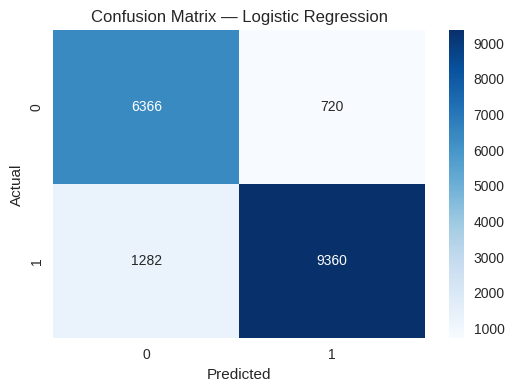

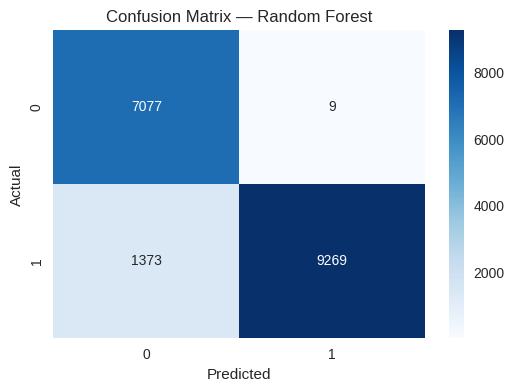

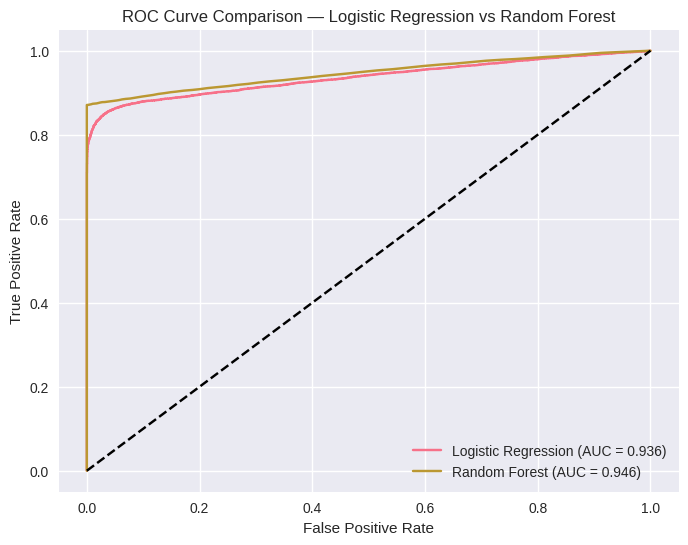

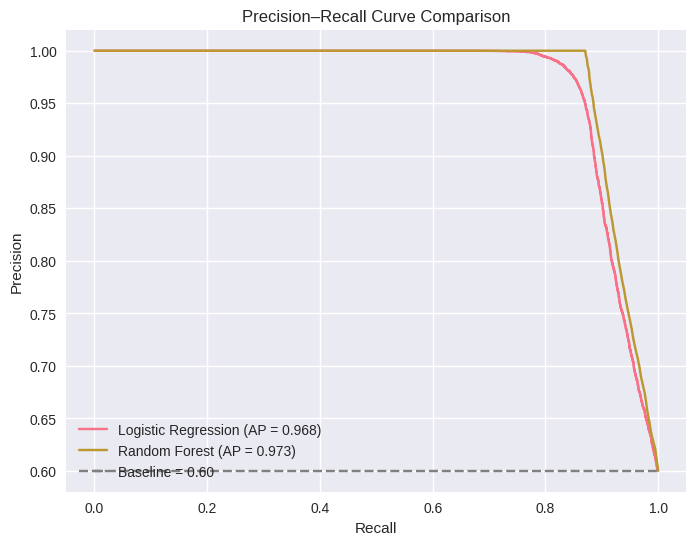

In [ ]:
# === Baseline Model 1: Logistic Regression ===

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

# Train on scaled features
log_reg.fit(X_train_scaled, y_train)

# Predictions on test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:   ", recall_score(y_test, y_pred_lr))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lr))

print("\nClassification report:\n", classification_report(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

# === Baseline Model 2: Random Forest ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

# === Comparison of Baselines ===

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Train on unscaled features
rf.fit(X_train, y_train)

# Predictions on test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:   ", recall_score(y_test, y_pred_rf))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))

print("\nClassification report:\n", classification_report(y_test, y_pred_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

#HEATMAP GENERATIONS for Logistic Regression Baseline and Random Forrest Baseline

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Function to plot confusion matrix heatmaps
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Logistic Regression confusion matrix
plot_confusion_matrix(y_test, y_pred_lr, "Confusion Matrix — Logistic Regression")

# Random Forest confusion matrix
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix — Random Forest")

# ROC Curves for Logistic Regression vs Random Forest

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")

plt.plot([0,1], [0,1], 'k--')  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Logistic Regression vs Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# === Precision-Recall Curve Comparison (Logistic Regression vs Random Forest) ===

from sklearn.metrics import precision_recall_curve, average_precision_score

# Logistic Regression PR values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
ap_lr = average_precision_score(y_test, y_proba_lr)

# Random Forest PR values
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(8,6))

# Plot curves
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.3f})")

# Baseline (mean positives)
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label=f"Baseline = {baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

(62045, 35) (13296, 35) (13296, 35)
Logistic Regression AUC: 0.9377357051106805
Random Forest AUC: 0.9449197630121292
Initial XGBoost AUC: 0.9424511157820565
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 5, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      5315
           1       1.00      0.87      0.93      7981

    accuracy                           0.92     13296
   macro avg       0.92      0.94      0.92     13296
weighted avg       0.94      0.92      0.92     13296



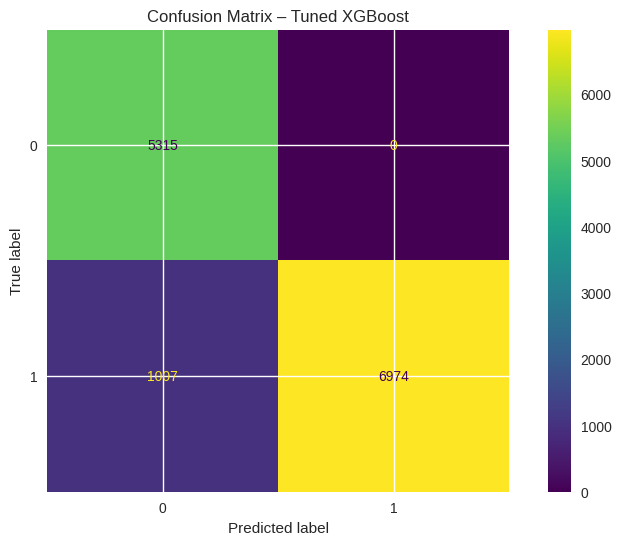

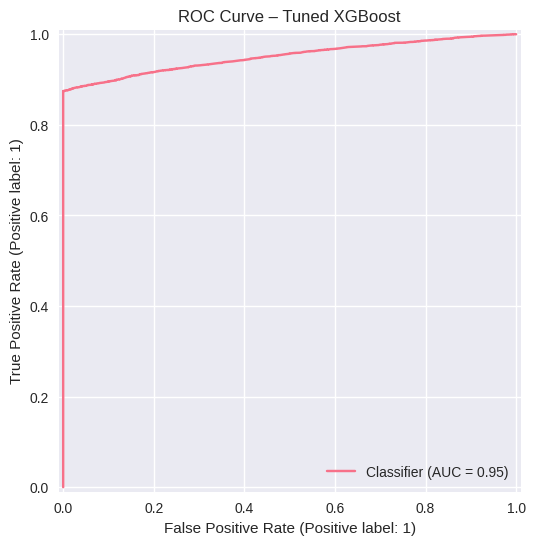

['best_xgb_model.pkl']

In [30]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df_feature.drop("diagnosed_diabetes", axis=1)
y = df_feature["diagnosed_diabetes"]

# Stratified split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
log_pred = log_reg.predict(X_val_scaled)
log_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val_scaled)[:,1])

rf_pred = rf.predict(X_val)
rf_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:,1])

print("Logistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

import xgboost as xgb

xgb_basic = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_basic.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score

basic_auc = roc_auc_score(y_val, xgb_basic.predict_proba(X_val)[:,1])
print("Initial XGBoost AUC:", basic_auc)

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [200, 400, 600, 800],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

best_model = random_search.best_estimator_

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]


from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix – Tuned XGBoost")
plt.show()


from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve – Tuned XGBoost")
plt.show()

import joblib
joblib.dump(best_model, "best_xgb_model.pkl")
